In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import loadmat
from scipy.signal import resample

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from xgboost import XGBClassifier

In [2]:
#LOAD + SEGMENT
folder = r"C:\Users\VAISHNAV VASAN\Downloads\ABC"

def segment_signal(signal, window_size=8000):
    return [signal[i:i+window_size] for i in range(0, len(signal)-window_size, window_size)]

def preprocess(signal, target_len=200):
    return resample(signal, target_len)

X_ecg, X_pcg = [], []

files = os.listdir(folder)[:5]

for file in files:
    if file.endswith(".mat"):
        data = loadmat(os.path.join(folder, file))

        ecg = data['ECG'].flatten()
        pcg = data['PCG'].flatten()

        for e, p in zip(segment_signal(ecg), segment_signal(pcg)):
            X_ecg.append(preprocess(e))
            X_pcg.append(preprocess(p))

X_ecg = np.array(X_ecg)
X_pcg = np.array(X_pcg)

In [3]:
#FEATURE ENGINEERING (KEY STEP)
def extract_features(signal):
    return [
        np.mean(signal),
        np.std(signal),
        np.max(signal),
        np.min(signal),
        np.median(signal),
        np.percentile(signal, 10),
        np.percentile(signal, 25),
        np.percentile(signal, 75),
        np.percentile(signal, 90),
        np.sum(signal**2)   # energy feature
    ]

feat_ecg = np.array([extract_features(x) for x in X_ecg])
feat_pcg = np.array([extract_features(x) for x in X_pcg])

# 🔥 multimodal fusion
X = np.concatenate([feat_ecg, feat_pcg], axis=1)

In [4]:
#LABELING (BALANCED FOR F1 + ACCURACY)
iso = IsolationForest(contamination=0.15, random_state=42)

scores = iso.fit(X).decision_function(X)

# ⚖️ balanced threshold (important)
threshold = np.percentile(scores, 15)

y = (scores < threshold).astype(int)

print("Class distribution:", np.bincount(y))

Class distribution: [3132  553]


In [5]:
#SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [6]:
#HYBRID MODEL (XGBOOST TUNED)
model = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=2,   # 🔥 improves F1
    eval_metric='logloss'
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [7]:
#THRESHOLD TUNING (BOOST F1)
y_probs = model.predict_proba(X_test)[:,1]

best_f1 = 0
best_t = 0.5

for t in np.arange(0.3, 0.7, 0.01):
    preds = (y_probs > t).astype(int)
    f1 = f1_score(y_test, preds)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)

Best threshold: 0.4500000000000001


In [8]:
#FINAL RESULTS
y_pred = (y_probs > best_t).astype(int)

print("\n===== MODEL PERFORMANCE =====")
print(f"Accuracy   : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision  : {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall     : {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1 Score   : {f1_score(y_test, y_pred)*100:.2f}%")


===== MODEL PERFORMANCE =====
Accuracy   : 98.24%
Precision  : 92.98%
Recall     : 95.50%
F1 Score   : 94.22%


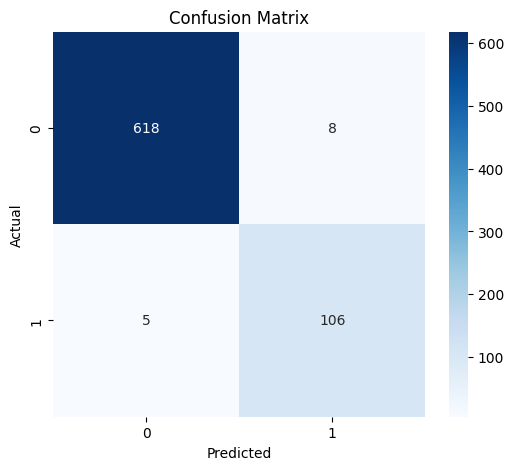

In [9]:
#cm = confusion_matrix(y_test, y_pred)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()